### 导入库

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import numpy as np
from scipy.io import loadmat
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

### 自定义 Dataset 类，加载数据集
原始SVHN 数据(.mat)的存储格式是 (高度, 宽度, 通道, 样本数)。

PyTorch中卷积层（Conv2d）期望的输入格式是 (批量大小, 通道, 高度, 宽度)。

故使用 np.transpose(data['X'], (3, 0, 1, 2)) 把样本数提到第一维，再通过 transforms.ToTensor() 把通道数提到第二维。

In [2]:
class SVHNDataset(Dataset):
    def __init__(self, file_path, transform=None):
        # 加载 .mat 文件
        data = loadmat(file_path)
        # 调整维度从 (32, 32, 3, N) 变为 (N, 32, 32, 3)
        self.images = np.transpose(data['X'], (3, 0, 1, 2))
        self.labels = data['y'].flatten()

        # 修正标签：将标签 10 映射为 0
        self.labels[self.labels == 10] = 0
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

#### 定义预处理

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 将 numpy (H, W, C) 转化为 tensor (C, H, W)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

#### 实例化 SVHNDataset

In [4]:
train_dataset = SVHNDataset('train_32x32.mat', transform=transform)
test_dataset = SVHNDataset('test_32x32.mat', transform=transform)

# 创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### 模型定义

#### 基础CNN模型

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(), nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

#### ResNet 残差块与 Tiny-ResNet

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x): return torch.relu(self.convs(x) + self.shortcut(x))

class TinyResNet(nn.Module):
    def __init__(self):
        super(TinyResNet, self).__init__()
        self.prep = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU())
        self.layer1 = ResidualBlock(32, 64, 2) # 16x16
        self.layer2 = ResidualBlock(64, 128, 2) # 8x8
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(128 * 8 * 8, 10))
    def forward(self, x): return self.fc(self.layer2(self.layer1(self.prep(x))))

### 定义训练与评估函数
每个 Epoch 结束后，立即在测试集上运行一次评估，以获取测试损失和测试准确率。

使用字典存储每一个 Epoch 的四项指标，以便后续绘图。

In [7]:
def train_model(model, name, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    res = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        t_loss, t_corr, t_total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward(); optimizer.step()
            t_loss += loss.item() * x.size(0)
            t_corr += (out.argmax(1) == y).sum().item(); t_total += y.size(0)

        model.eval()
        v_loss, v_corr, v_total = 0, 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x); loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                v_corr += (out.argmax(1) == y).sum().item(); v_total += y.size(0)

        res['train_loss'].append(t_loss/t_total); res['test_loss'].append(v_loss/v_total)
        res['train_acc'].append(t_corr/t_total); res['test_acc'].append(v_corr/v_total)
        print(f"[{name}] Epoch {epoch+1} Test Acc: {res['test_acc'][-1]:.4f}")
    return res

### 执行训练和结果对比

[SimpleCNN] Epoch 1 Test Acc: 0.8320
[SimpleCNN] Epoch 2 Test Acc: 0.8529
[SimpleCNN] Epoch 3 Test Acc: 0.8666
[SimpleCNN] Epoch 4 Test Acc: 0.8672
[SimpleCNN] Epoch 5 Test Acc: 0.8738
[SimpleCNN] Epoch 6 Test Acc: 0.8765
[SimpleCNN] Epoch 7 Test Acc: 0.8778
[SimpleCNN] Epoch 8 Test Acc: 0.8847
[SimpleCNN] Epoch 9 Test Acc: 0.8903
[SimpleCNN] Epoch 10 Test Acc: 0.8825
[ResNet] Epoch 1 Test Acc: 0.8819
[ResNet] Epoch 2 Test Acc: 0.9066
[ResNet] Epoch 3 Test Acc: 0.9209
[ResNet] Epoch 4 Test Acc: 0.9162
[ResNet] Epoch 5 Test Acc: 0.9207
[ResNet] Epoch 6 Test Acc: 0.9084
[ResNet] Epoch 7 Test Acc: 0.9154
[ResNet] Epoch 8 Test Acc: 0.9161
[ResNet] Epoch 9 Test Acc: 0.9147
[ResNet] Epoch 10 Test Acc: 0.9180


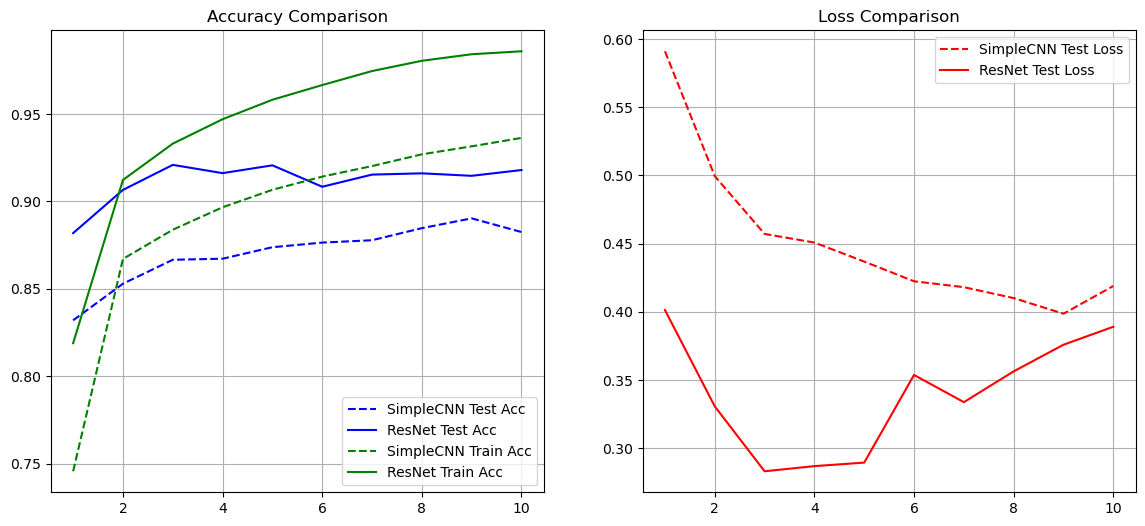

In [8]:
cnn_history = train_model(SimpleCNN(), "SimpleCNN", epochs=10)
resnet_history = train_model(TinyResNet(), "ResNet", epochs=10)

# 绘图对比
plt.figure(figsize=(14, 6))
epochs_range = range(1, 11)

# 准确率对比
plt.subplot(1, 2, 1)
plt.plot(epochs_range, cnn_history['test_acc'], 'b--', label='SimpleCNN Test Acc')
plt.plot(epochs_range, resnet_history['test_acc'], 'b-', label='ResNet Test Acc')
plt.plot(epochs_range, cnn_history['train_acc'], 'g--', label='SimpleCNN Train Acc')
plt.plot(epochs_range, resnet_history['train_acc'], 'g-', label='ResNet Train Acc')
plt.title('Accuracy Comparison')
plt.legend(); plt.grid()

# 损失对比
plt.subplot(1, 2, 2)
plt.plot(epochs_range, cnn_history['test_loss'], 'r--', label='SimpleCNN Test Loss')
plt.plot(epochs_range, resnet_history['test_loss'], 'r-', label='ResNet Test Loss')
plt.title('Loss Comparison')
plt.legend(); plt.grid()
plt.show()

由训练结果绘图可知，加入了残差网络ResNet后，整体准确率有明显上升。
随着训练轮数的增加，训练集的准确率一直在上升；而测试集的准确率在训练初期稳步上升，第五轮过后开始震荡，Loss曲线也在第五轮开始不再单调下降吗，可能是设计的CNN网络和ResNet网络均存在过拟合。